<a href="https://colab.research.google.com/github/AquilaITOH/MedicalDataScience-exercises/blob/main/26_Medical-DataScience_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# メディカルデータサイエンス #4 データの可視化と古典的機械学習
- 散布図による可視化
  - 行列の演算 和、積、アダマール積
  - 面積での評価
- データの次元
  - 次元削減
  - 散布図行列 (pair plot)
  - 主成分分析
- 分類器
  - 古典的機械学習
  - 各種分類器の比較
- 深層学習へ



#データ分析の準備 (前回同様)
## ライブラリ・モジュールの読み込み p.104

ライブラリを読み込む。

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.express as px #interactive plot
import seaborn as sns
import sklearn.decomposition as decomposition
import sklearn.datasets as datasets
import sklearn.decomposition as decomposition
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

## data setの読み込みとDFへのセット
Iris data setを読み込み、Pandas DataFrameにセットする

In [ ]:
import sklearn.datasets as datasets
iris_data = datasets.load_iris()

iris_df = pd.DataFrame(iris_data.data, columns = iris_data.feature_names)
iris_df["species"] = iris_data.target_names[iris_data.target]
iris_df.head(5)

## matplotlobで日本語ラベルのグラフを描画する p.107 (前回同様)

グラフ内のラベルに日本語を使いたい場合は cjk フォントインストール＆キャッシュ再構築が必要

In [ ]:
# ① フォントインストール（初回のみ）
!apt-get install -y fonts-noto-cjk

import matplotlib.font_manager as fm

# ② キャッシュを強制再構築（これが重要）
fm.fontManager.__init__()  # または下記の方法

# ③ 登録されているフォント名を確認
noto_fonts = [f.name for f in fm.fontManager.ttflist if 'Noto' in f.name]
print(set(noto_fonts))

## 散布図 (花弁の長さ, 花弁の幅)

軸ラベルに日本語使用可能

In [ ]:
species_jp = {'setosa': 'セトサ', 'versicolor': 'バーシカラー', 'virginica': 'バージニカ'}
colors = {'setosa': 'tab:blue', 'versicolor': 'tab:orange', 'virginica': 'tab:green'}

plt.figure(figsize=(4,4), dpi=200)
for species, group in iris_df.groupby('species'):
    plt.plot(group["petal length (cm)"], group["petal width (cm)"],
             ".", label=species_jp[species], color=colors[species])

plt.xlabel("花弁の長さ (cm)")
plt.ylabel("花弁の幅 (cm)")
plt.legend(title="品種")
plt.show()

# データの分析 p.109

## 長さの次元での評価
上のグラフはpetal:花弁の長さとsepal:ガクの長さの散布図である。

## 面積の次元での評価
irisデータセットは花弁の長さと幅、ガクの長さと幅の4種類の計測値を持っている。上のグラフは長さだけで比較しているが、データ分析としてそれで良いのか?

長さと幅を**掛け算をして面積で評価**してはどうだろうか。


# 行列演算のための数学

### 行列の和

行列は高校数学で扱わなくなった。理学部、工学部等では大学数学の「線形代数」で扱う。

- おすすめ参考書
[高松, 瑞代. 応用がみえる線形代数.(東京: 岩波書店,2020)](https://www.amazon.co.jp/%E5%BF%9C%E7%94%A8%E3%81%8C%E3%81%BF%E3%81%88%E3%82%8B%E7%B7%9A%E5%BD%A2%E4%BB%A3%E6%95%B0-Iwanami-Mathematics-%E9%AB%98%E6%9D%BE-%E7%91%9E%E4%BB%A3/dp/4000051318)

行列和は各項の和をとる。

In [ ]:
# 1行4列の行列array1, array2を準備
array1 = np.array([1,2,3,4])
array2 = np.array([5,6,7,8])

In [ ]:
# 項ごとに和をとって表示
print(array1 ,"+", array2,"=",array1 + array2)

### アダマール積

各項の積をとる。和と同じ手順。

In [ ]:
# 項ごとに積をとって表示
print(array1 ,"*", array2,"=",array1 * array2)

### 行列の積

行列の積はドット積の方が一般的。それぞれの項の積をとって、その総和をとる。

In [ ]:
# 1行3列の行列array_price, 3行1列のarray_qtyを準備
array_price = np.array([100, 150, 50])
array_qty = np.array([ [3],
                   [2],
                   [10] ])

各項の積をとった上で、総和をとる。

リンゴ100円, バナナ150円, みかん50円

リンゴ3個

バナナ2房

みかん10個

In [ ]:
print(np.dot(array_price, array_qty))

### アダマール積で長さと幅を掛け算して面積の次元にする p.110

それぞれの花の 長さ ×　幅 なのでアダマール積を使う。

長さの評価とはまた違った傾向が現れた。
花弁の面積がとても小さいグループがありそう。
おそらくSetosa

In [ ]:
species_jp = {'setosa': 'セトサ', 'versicolor': 'バーシカラー', 'virginica': 'バージニカ'}
colors = {'setosa': '#1f77b4', 'versicolor': '#ff7f0e', 'virginica': '#2ca02c'}

plt.figure(figsize=(4,4), dpi=200)
for species, group in iris_df.groupby('species'):
    plt.plot(
        group["petal length (cm)"] * group["petal width (cm)"],
        group["sepal length (cm)"] * group["sepal width (cm)"],
        ".", label=species_jp[species], color=colors[species]
    )

plt.xlabel("花弁の面積 (cm²)")
plt.ylabel("がくの面積 (cm²)")
plt.legend(title="品種")
plt.show()

# データの「次元」
irisはそれぞれの項目についてSepal length, Sepal width, Petal length, Petal widthの4つのパラメータをもつ。これを __4次元のデータ__ と表現する。データサイエンスでは数百次元のデータを日常的に扱う。


# 次元削減

視覚化するには最低1次元削減して3次元以下にする必要がある。

Iris data setは(がくの長さ, がくの幅, 花弁の長さ, 花弁の幅)の4次元

- 分離の良さそうな3次元を選択して 3次元プロット
- 分離の良さそうな2次元を選択して 2次元プロット
- 2次元の組み合わせ6パターンで $$_4 C _2 = 6 $$ 通り

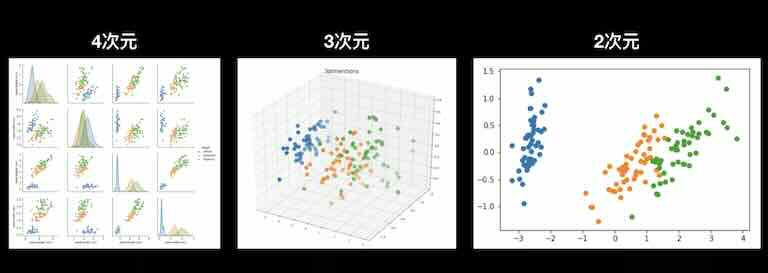

[【scikit-learn】iris(アイリス)データの主成分分析による次元削減と視覚化](https://fresopiya.com/2019/06/05/irispca/)

## 三次元プロット
1次元減らして三次元プロットを試みる。

Sepal widthは最も重なりが大きいので省略する。残りの3次元、Petal length, Petal width, Sepal lengthで3D plotする。

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
# Figureを追加
fig = plt.figure(figsize = (8, 8))

# 3DAxesを追加
ax = fig.add_subplot(111, projection='3d')

# Axesのタイトルを設定
ax.set_title("", size = 10)

# 軸ラベルを設定
ax.set_xlabel("petal length", size = 14, color = "r")
ax.set_ylabel("petal width", size = 14, color = "r")
ax.set_zlabel("sapal length", size = 14, color = "r")
# print(iris_df[iris_df["species"] == 'setosa'].iloc[:,1])

ax.scatter(iris_df[iris_df["species"] == 'setosa'].iloc[:,2],
           iris_df[iris_df["species"] == 'setosa'].iloc[:,3],
           iris_df[iris_df["species"] == 'setosa'].iloc[:,0], s=40, marker="s", c='tab:blue', edgecolor='black', label="setosa")
ax.scatter(iris_df[iris_df["species"] == 'versicolor'].iloc[:,2],
           iris_df[iris_df["species"] == 'versicolor'].iloc[:,3],
           iris_df[iris_df["species"] == 'versicolor'].iloc[:,0], s=40, marker="x", c='tab:orange',edgecolor='black', label="versicolor")
ax.scatter(iris_df[iris_df["species"] == 'virginica'].iloc[:,2],
           iris_df[iris_df["species"] == 'virginica'].iloc[:,3],
           iris_df[iris_df["species"] == 'virginica'].iloc[:,0], marker="o", c='tab:green',edgecolor='black', label="virginica")
ax.legend()
plt.show()

## インタラクティブプロット(花弁の長さ, 花弁の幅, がくの長さ)

上と同様に、(Petal length, Petal width, Sepal length)の3次元で3D plotした。
マウスで操作できます。

In [ ]:
# プロットを作成
fig = px.scatter_3d(
    iris_df,
    x="sepal length (cm)",  # x軸: 花びらの長さ
    y="petal length (cm)",   # y軸: 花びらの幅
    z="petal width (cm)",  # z軸: がく片の長さ
    color="species",        # 色分け: 列名を指定
    color_discrete_map={                # 色の対応をここで指定
        'setosa':     '#1f77b4',
        'versicolor': '#ff7f0e',
        'virginica':  '#2ca02c'
    },
    symbol="species",
    symbol_map={
        'setosa':     'square',
        'versicolor': 'x',
        'virginica':  'circle'
    },
    labels={"species": "Species",
            "petal length (cm)": "Petal Length (cm)",
            "petal width (cm)": "Petal Width (cm)",
            "sepal length (cm)": "Sepal Length (cm)"},
)

# プロットを表示

fig.update_traces(marker=dict(size=4, line=dict(color='black', width=1)))
fig.show()

## 散布図行列 (p.111)

データ全体を見やすく可視化する。

同時に可視化できるのは2変数のみ。2変数の組み合わせを片っ端から可視化する。

→ 分類に使えそうなものを探す

下記は教科書のコードを修正、改良したもの

In [ ]:
columns = iris_data.feature_names
count = len(columns)
figure = plt.figure(figsize=(10, 10), dpi=200)

# 色を指定
colors = {'setosa': 'tab:blue', 'versicolor': 'tab:orange', 'virginica': 'tab:green'}

for y in range(count):
    for x in range(count):
        if y == 0 and x == 0:
            graph = figure.add_subplot(count, count, 1 + y * count + x)
            graph_1 = graph
        else:
            graph = figure.add_subplot(count, count, 1 + y * count + x, sharex=graph_1, sharey=graph_1)
        if x == 0:
            graph.set_ylabel(columns[y])
        if y == count - 1:
            graph.set_xlabel(columns[x])
        # 品種ごとにscatterでプロット
        for species in iris_data.target_names:
            picked_data = iris_df[iris_df["species"] == species]
            graph.scatter(picked_data[columns[x]], picked_data[columns[y]], label=species, color=colors[species], alpha=0.7)
        graph.set_xlim(0, 8)
        graph.set_ylim(0, 8)

# 凡例を追加
handles, labels = graph_1.get_legend_handles_labels()
figure.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.15, 1), title="Species")

plt.show()


###  別のライブラリ "seabone"
前回の最後で紹介したもの。

seaborn.pairplot() を使用すると、一行で全ての特徴量の組み合わせを可視化できる。


In [ ]:
# ペアプロットの作成
sns.pairplot(iris_df, hue='species', markers=["o", "s", "X"],corner=True, height=1.5) #hueで品種ごとの色分け、corner=Trueで重複するplotを省略
plt.show()

### 組み合わせの中から品種の分類に都合の良さそうな組み合わせを探す

- Sepal widthは品種が違っても重なりが大きいことがわかる。→ 3D表示時に省略した
  - Sepal lengthも重なりが大きい。sepal width/ sepal lengthの 散布図は分類に不向き
- Petal width/ Petal length の 散布図がもっとも良さそう。

## 主成分分析 p.110
古典的な方法。

データの次元(花弁(幅、長さ)、がく(幅、長さ) 4次元)を減らして要約する。

→ 4次元はグラフにできない！

データの要素からデータの特徴を表す「主成分」を生成し、データの要約を試みる。

→ 2次元、3次元ならグラフ化できる

[主成分分析とは? 例を使って活用方法とメリットをわかりやすく解説](https://www.nttcoms.com/service/research/dataanalysis/principal-component-analysis/)

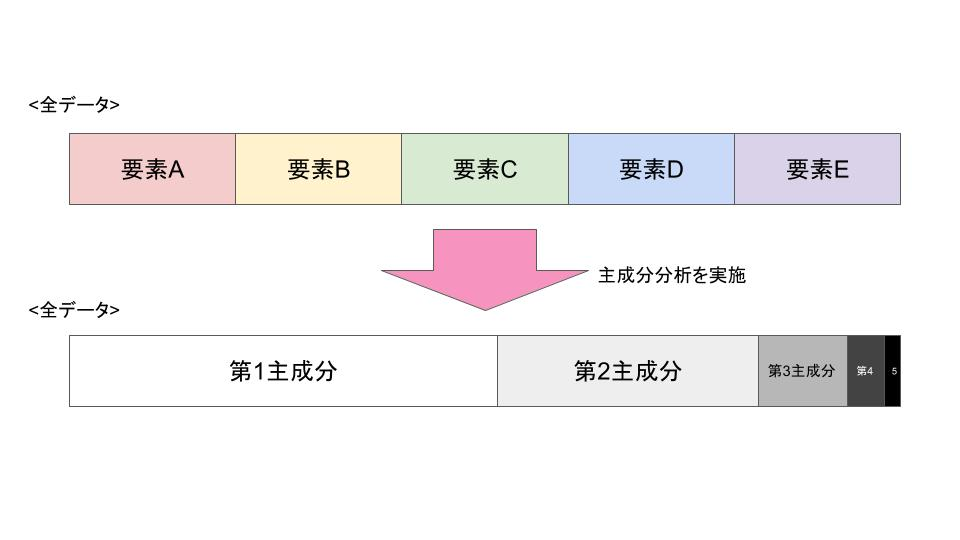

主成分は元の変数に主成分係数がかかっている。**変数そのものではない。**

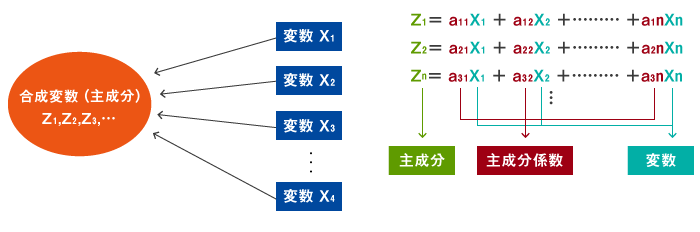

In [ ]:
pca = decomposition.PCA()
pca.fit(iris_data.data)
transformed_data = pca.transform(iris_data.data)

species_jp = {'setosa': 'セトサ', 'versicolor': 'バーシクラー', 'virginica': 'バージニカ'}
colors = {'setosa': 'tab:blue', 'versicolor': 'tab:orange', 'virginica': 'tab:green'}

plt.figure(figsize=(4,4), dpi=200)
for species, idx in zip(iris_data.target_names, range(3)):
    mask = iris_data.target == idx
    plt.plot(transformed_data[mask, 0], transformed_data[mask, 1],
             ".", label=species_jp[species], color=colors[species])

plt.xlabel("第一主成分")
plt.ylabel("第二主成分")
plt.legend(title="品種")
plt.show()

### 結果の評価

第一主成分と第二主成分で2分類はできる。

3分類は?

花弁の幅/ がくの幅 の散布図と同程度の分離か。手間をかけた割には報われなかった…

# データの分類

ここからは散布図にどのように線を引けば3種類を分類できるか考えていく。


二次元散布図(花弁の長さ, 花弁の幅)ではバーシカラーとバージニカに境界線を引きにくいようだ。

三次元プロットを見ると、斜めに境界面を入れれば二次元よりはうまく分類できそうだ。

## 分類器

- 一本の線で分類できる→ 線形分類器
- 複数の線を組み合わせて分類する→ 非線形分類器


### 線形分類器
線形分離可能なデータであれば、線形分類器で分離できる。
- ロジスティック回帰
- 線型判別分析
- ナイーブベイズ分類器
- SVM (Support Vector Machie 主成分分析(PCA)と併用することもある)

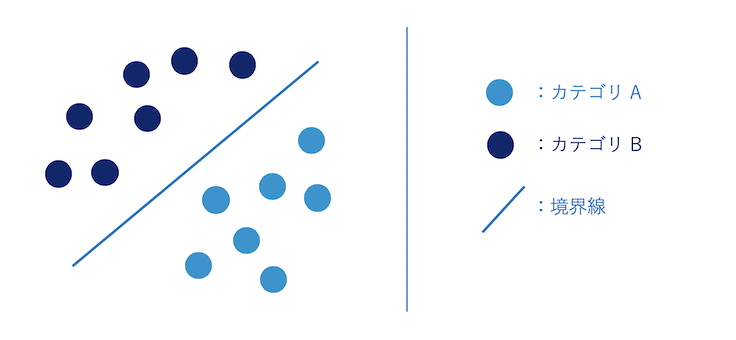

[機械学習 実践（教師あり学習：分類） - KIKAGAKU](https://free.kikagaku.ai/tutorial/basic_of_machine_learning/learn/machine_learning_classification)

### 非線形分類器
一本の線で部類できなさそうならば、非線形分類器を使う

Irisは三種類の境界が入り組んでいる→ 直線を複数組み合わせて分類するのが自然であろう
- k-近傍法
- 決定木
- ニューラルネットワーク

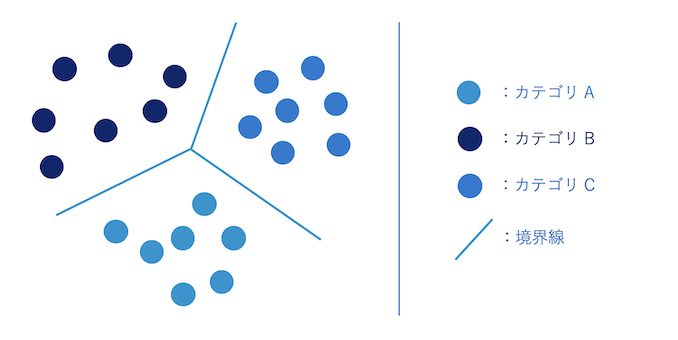


# 古典的機械学習

## 統計的機械学習

ロジスティック回帰や線型判別分析、ナイーブベイズなど、統計学的な理論に基づいたモデルを指す際に使われます。

古典的モデルは人間が「どのデータ（変数）が重要か」をあらかじめ設計して与えるプロセスを重視する。

## 古典的機械学習による分類器での分類 (山崎先生ご提供)

- データの準備
- 特徴量(X)と正解ラベル(y)を分離
- 訓練データ(train)とテストデータ(test)に分割(8:2)
- 特徴量は4次元全部使用する。sepal length (cm), sepal width (cm), petal length (cm), petal width (cm)

In [ ]:
X = iris_df.drop(["species"], axis=1)# speciesを除いた、特徴量（sepal length (cm), sepal width (cm), petal length (cm), petal width (cm)）
y = iris_df["species"] #　正解ラベル
print(f"X shape: {X.shape} | y shape: {y.shape} ")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=2
)
print(
    f"X train shape: {X_train.shape} | X test shape: {X_test.shape} | y train shape: {y_train.shape} y shape: {y_test.shape} "
)

## 各種分類器を試す

### クロスバリデーション:

StratifiedKFold を用いて、データセットを10分割し、層化サンプリング（ターゲットのクラス分布を保つ）を行いながらモデルを評価しする。

cross_val_score により、各モデルの精度を10回の分割で計算。

## 評価指標:
- モデルの 精度 (accuracy) を用いて評価。
- 各モデルの平均精度と標準偏差を出力。

In [ ]:
models = []
models.append(("LR", LogisticRegression())) #ロジスティック回帰
models.append(("LDA", LinearDiscriminantAnalysis())) #線型判別分析
models.append(("NB", GaussianNB()))  #ナイーブベイズクラス分類器
models.append(("SVC", SVC(gamma="auto"))) #サポートベクターマシン
models.append(("KNN", KNeighborsClassifier())) #k-近傍法(非線形分類器)
models.append(("CART", DecisionTreeClassifier()))  #決定木(非線形分類器)
results = []
model_names = []
for name, model in models:
    kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring="accuracy")
    results.append(cv_results)
    model_names.append(name)
    print("%s: %f (%f)" % (name, cv_results.mean(), cv_results.std()))#10回の平均値と標準偏差に基づいた、accuray

### SVCでの分類を評価

SVCの精度が良さそうなので、テストデータでaccuracyを改めて評価する。

In [ ]:
# SVCが一番良さそうなので、テストデータでaccuracyを改めて評価
model = SVC(gamma="auto")
model.fit(X_train, y_train)
prediction = model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, prediction)}")
print(f"Classification Report: \n {classification_report(y_test, prediction)}")

# ラベル（species）を数値に変換（色付けに使うため）
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

print("クラスの対応：")
for i, class_name in enumerate(le.classes_):
    print(f"{i} → {class_name}")

### テストデータの分類結果を散布図で表示

In [ ]:
# テストデータの分類結果を散布図に

# y_train で使ったエンコーダを再利用
# （もしくは学習時に使った LabelEncoder `le` を使ってください）
le = LabelEncoder()
le.fit(y_train)  # すでに fit してるならこの行は不要です

# y_test, prediction を数値に変換
y_test_encoded = le.transform(y_test)
prediction_encoded = le.transform(prediction)

# 散布図の描画
plt.figure(figsize=(6, 4.5))
scatter = plt.scatter(
    X_test["petal length (cm)"],
    X_test["petal width (cm)"],
    c=prediction_encoded,     # 数値ラベル
    cmap="viridis",
    s=60,
    edgecolors='k',
    alpha=0.8
)
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("SVC Prediction Results (Test Data)")

# 凡例の作成
unique_classes = np.unique(prediction_encoded)
legend_handles = [
    mpatches.Patch(color=plt.cm.viridis(i / 2), label=le.inverse_transform([i])[0])
    for i in unique_classes
]
plt.legend(handles=legend_handles, title="Predicted Class")
plt.grid(True)
plt.show()

### 正解ラベルを使って散布図を表示

正解ラベルを使って散布図を作り、SVCによるテストデータの分類結果と比較する

In [ ]:
#正解ラベルを使って散布図を作り、上図と比較しましょう
plt.figure(figsize=(6, 4.5))
scatter = plt.scatter(
    X_test["petal length (cm)"],
    X_test["petal width (cm)"],
    c=y_test_encoded,        # ← 正解ラベルを使う
    cmap="viridis",
    s=60,
    edgecolors='k',
    alpha=0.8
)
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Ground Truth Labels (Test Data)")

# 凡例の作成
unique_classes = np.unique(y_test_encoded)
legend_handles = [
    mpatches.Patch(color=plt.cm.viridis(i / 2), label=le.inverse_transform([i])[0])
    for i in unique_classes
]
plt.legend(handles=legend_handles, title="True Class")
plt.grid(True)
plt.show()

#　ほぼ一緒の図でしょうか！？だとすると、正しく分類できたということでしょう

## 結果の評価

ほぼ一緒の図でしょうか！？だとすると、正しく分類できたということでしょう

# 古典的機械学習に対する深層学習

## 歴史的な位置付け

- 第一次ブーム（1950〜60年代）— 記号処理・神経回路の黎明期

  - ルールベース（専門家が手書きしたif-thenルールによる推論）
  - パーセプトロン（単層ニューラルネット、線形分離のみ可能）

- 第二次ブーム（1980〜90年代）— 統計的機械学習の確立

  - ロジスティック回帰（確率的2値分類の基礎）
  - ナイーブベイズ（ベイズ定理に基づくテキスト分類などに活躍）
  - 決定木（可解釈性の高いルール学習）
  - KNN（距離ベースの非パラメトリック分類）
  - SVM / SVC（カーネル法により非線形分類が可能、1990年代に発展）

- 第三次ブーム（2010年代〜現在）— 深層学習・大規模モデルの時代

  - DNN（深い多層構造、誤差逆伝播＋GPU計算で実用化）
  - CNN（畳み込みによる画像特徴の自動抽出、AlexNet以降に普及）
  - Transformer（自己注意機構による系列処理、LLMの基盤）